# Ejercicio 5: Estudio y aplicación del algoritmo Naive Bayes


## 1. Fundamentación teórica

**Naive Bayes** (Bayes ingenuo) es un clasificador supervisado basado en el **teorema de Bayes**. Calcula la probabilidad a posteriori de que una instancia $X = (x_1, x_2, \dots, x_n)$ pertenezca a la clase $C_k$:

$$P(C_k \mid X) = \frac{P(X \mid C_k)\, P(C_k)}{P(X)}$$

donde:

- $P(C_k \mid X)$: probabilidad **a posteriori** de la clase $C_k$ dada la instancia.
- $P(X \mid C_k)$: **verosimilitud** (*likelihood*) de observar $X$ si la clase es $C_k$.
- $P(C_k)$: probabilidad **a priori** de la clase.
- $P(X)$: **evidencia**, constante respecto a la clase (solo normaliza).

### El supuesto «ingenuo»

Se asume que las características son **condicionalmente independientes** dada la clase:

$$P(X \mid C_k) = \prod_{i=1}^{n} P(x_i \mid C_k)$$

Con este supuesto no hace falta estimar la distribución conjunta de las $n$ variables, cuyo número de parámetros crece de forma exponencial con $n$. Basta estimar $n$ distribuciones univariadas por clase, así que el número de parámetros crece de forma **lineal** y el entrenamiento es muy rápido. La clase predicha es

$$\hat{y} = \arg\max_{k} \left[ \log P(C_k) + \sum_{i=1}^{n} \log P(x_i \mid C_k) \right]$$

(se usan logaritmos para evitar el desbordamiento por producto de muchas probabilidades pequeñas).

## 2. Variantes principales

| Variante | Tipo de atributos | Modelo de $P(x_i \mid C_k)$ | Uso típico |
|---|---|---|---|
| **Gaussian NB** | Continuos | Normal $\mathcal{N}(\mu_{ik}, \sigma_{ik}^2)$ | Mediciones, datos clínicos |
| **Multinomial NB** | Conteos / frecuencias | Multinomial | Clasificación de texto |
| **Bernoulli NB** | Binarios | Bernoulli | Presencia/ausencia de palabras o rasgos |

En este ejercicio se usa **Gaussian NB**, porque todos los atributos del dataset son medidas continuas.

## 3. Aplicación: diagnóstico de cáncer de mama

Se usa el dataset *Breast Cancer Wisconsin (Diagnostic)* incluido en scikit-learn: 569 pacientes, 30 características numéricas calculadas a partir de imágenes de biopsia y una etiqueta de diagnóstico (**0 = maligno, 1 = benigno**).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
)

SEED = 42
sns.set_theme(style="whitegrid")

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = maligno, 1 = benigno

print(f"Dimensiones del dataset: {X.shape[0]} muestras, {X.shape[1]} características")
print("Distribución de clases:")
print(f"  - Maligno (0): {(y == 0).sum()}")
print(f"  - Benigno (1): {(y == 1).sum()}")

# 80 % entrenamiento / 20 % prueba, conservando la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nMuestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba:        {X_test.shape[0]}")

Dimensiones del dataset: 569 muestras, 30 características
Distribución de clases:
  - Maligno (0): 212
  - Benigno (1): 357

Muestras de entrenamiento: 455
Muestras de prueba:        114


## 4. Entrenamiento y evaluación

In [2]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
y_probs = gnb.predict_proba(X_test)[:, 1]      # probabilidad de la clase 1 (benigno)

# Métricas con "benigno" (1) como clase positiva
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 55)
print("MÉTRICAS DEL CLASIFICADOR NAIVE BAYES (conjunto de prueba)")
print("=" * 55)
print(f"Exactitud (Accuracy):          {acc:.4f}")
print(f"Precisión (Precision):         {prec:.4f}")
print(f"Sensibilidad (Recall):         {rec:.4f}")
print(f"Puntuación F1:                 {f1:.4f}")
print("\nReporte detallado por clase:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

MÉTRICAS DEL CLASIFICADOR NAIVE BAYES (conjunto de prueba)
Exactitud (Accuracy):          0.9386
Precisión (Precision):         0.9452
Sensibilidad (Recall):         0.9583
Puntuación F1:                 0.9517

Reporte detallado por clase:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



Las métricas anteriores toman **benigno** como clase positiva. En un diagnóstico médico lo más grave es un **falso negativo para maligno** (un tumor maligno clasificado como benigno), así que conviene mirar la sensibilidad de la clase *maligno*, que es el recall de la clase 0.

In [3]:
recall_maligno = recall_score(y_test, y_pred, pos_label=0)
precision_maligno = precision_score(y_test, y_pred, pos_label=0)
print(f"Sensibilidad para MALIGNO (recall clase 0): {recall_maligno:.4f}")
print(f"Precisión para MALIGNO (precision clase 0): {precision_maligno:.4f}")

Sensibilidad para MALIGNO (recall clase 0): 0.9048
Precisión para MALIGNO (precision clase 0): 0.9268


## 5. Matriz de confusión y curva ROC

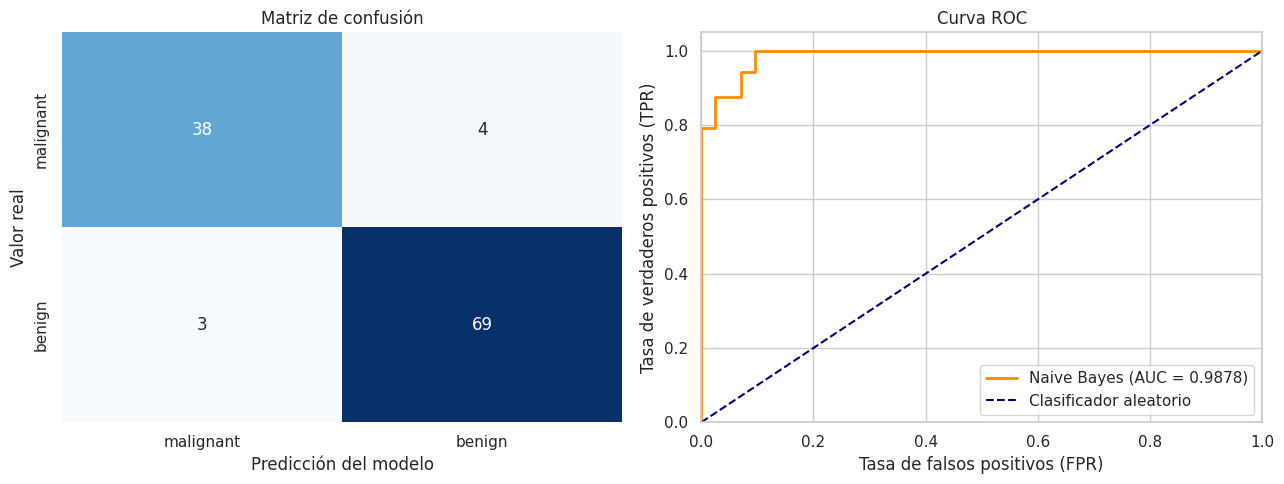

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1) Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0])
axes[0].set_title("Matriz de confusión", fontsize=12)
axes[0].set_xlabel("Predicción del modelo")
axes[0].set_ylabel("Valor real")

# 2) Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"Naive Bayes (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Clasificador aleatorio")
axes[1].set_xlim(0.0, 1.0)
axes[1].set_ylim(0.0, 1.05)
axes[1].set_xlabel("Tasa de falsos positivos (FPR)")
axes[1].set_ylabel("Tasa de verdaderos positivos (TPR)")
axes[1].set_title("Curva ROC", fontsize=12)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 6. Robustez de la evaluación: validación cruzada

Con un único corte 80/20 el resultado depende de qué pacientes cayeron en el conjunto de prueba (solo 114). Se repite la evaluación con **validación cruzada estratificada de 5 particiones**.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}
res = cross_validate(GaussianNB(), X, y, cv=cv, scoring=scoring)

resumen = pd.DataFrame({
    "Media": {m: res[f"test_{m}"].mean() for m in scoring},
    "Desv. estándar": {m: res[f"test_{m}"].std() for m in scoring},
})
resumen.index.name = "Métrica (5-fold)"
resumen.round(4)

,Media,Desv. estándar
Métrica (5-fold),,
accuracy,0.9385,0.0235
precision,0.9368,0.0334
recall,0.9692,0.0310
f1,0.9520,0.0181
roc_auc,0.9887,0.0056


## 7. Verificación del supuesto de independencia

Naive Bayes supone que las características son independientes dada la clase. Se comprueba qué tan razonable es esto en el dataset midiendo la correlación entre características (aquí, sobre todo el dataset y sin condicionar por clase, como indicador aproximado).

In [6]:
corr = X.corr().abs()
pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
n_pares = len(pares)
n_altas = int((pares > 0.8).sum())
print(f"Pares de características: {n_pares}")
print(f"Pares con |correlación| > 0.8: {n_altas} ({100 * n_altas / n_pares:.1f} %)")

top = pares.sort_values(ascending=False).head(5)
print("\nPares más correlacionados:")
for (a, b), v in top.items():
    print(f"  {a}  <->  {b}: {v:.3f}")

Pares de características: 435
Pares con |correlación| > 0.8: 44 (10.1 %)

Pares más correlacionados:
  mean radius  <->  mean perimeter: 0.998
  worst radius  <->  worst perimeter: 0.994
  mean radius  <->  mean area: 0.987
  mean perimeter  <->  mean area: 0.987
  worst radius  <->  worst area: 0.984


## 8. Conclusiones

**Resultados.** El clasificador Gaussian Naive Bayes distingue bien los tumores malignos de los benignos: en el conjunto de prueba obtiene una exactitud de ≈ 0,94 y un AUC de ≈ 0,99, y la validación cruzada de 5 particiones confirma el resultado (exactitud media ≈ 0,94, con una desviación de ≈ 0,02 entre particiones). La matriz de confusión muestra, sin embargo, que **4 de los 42 tumores malignos de prueba se clasificaron como benignos** (sensibilidad para maligno ≈ 0,90). En un contexto clínico este es el error más costoso, así que un modelo así serviría como apoyo y no como diagnóstico definitivo, y habría que ajustar el umbral de decisión para priorizar la sensibilidad de la clase maligna.

**Ventajas**

1. **Rápido y escalable.** Entrenar consiste en calcular medias, varianzas y frecuencias por clase; la predicción es una suma de logaritmos.
2. **Funciona con pocos datos.** Al estimar solo distribuciones univariadas, necesita menos ejemplos que modelos más flexibles.
3. **Probabilístico e interpretable.** Entrega probabilidades de clase y cada atributo aporta un término explícito a la decisión.
4. **Relativamente tolerante a atributos irrelevantes**, porque cada uno aporta un factor independiente que tiende a ser poco informativo.

**Desventajas**

1. **El supuesto de independencia rara vez se cumple.** En este dataset hay 44 pares de características con correlación mayor a 0,8, entre ellos radio, perímetro y área de un mismo tumor, con correlaciones de 0,98 o más (ver sección 7). Aun así el modelo clasifica bien, pero la información redundante se cuenta varias veces y las probabilidades que entrega suelen quedar *mal calibradas* (demasiado cercanas a 0 o 1). Modelos como la regresión logística, SVM o Random Forest suelen superarlo cuando hay muchas características correlacionadas.
2. **Problema de frecuencia cero** (variantes categóricas, como Multinomial o Bernoulli): si un valor no aparece con una clase en el entrenamiento, su probabilidad es 0 y anula todo el producto. Se corrige con **suavizado de Laplace** (parámetro `alpha` en scikit-learn). En Gaussian NB el equivalente práctico es `var_smoothing`, que evita varianzas nulas.
3. **Supuesto de distribución.** Gaussian NB asume que cada atributo es normal dentro de cada clase; si no lo es, el ajuste empeora.